# Phase 5 — reading the result

**Corrected arm only.** Covers the pipeline's Steps 9 to 11: Manhattan plots, QQ plots and the
tables. The chromosome merge (her Step 9.1) was pulled forward into Phase 4, because it was needed
to compare against her results, and is not repeated here.

What Phase 4 established, which this notebook shows rather than asserts:

- no gene reaches exome-wide significance in any cohort, in **either** arm
- the analysis is calibrated, so that absence is real rather than a deflated test
- the ranking underneath the null moves a great deal, and her rank-1 gene is one we never tested

Everything is drawn by [`../scripts/burden_plots.py`](../scripts/burden_plots.py), so the Portuguese
version of this notebook produces identical figures.

## Setup

`bp.hers()` drops rows rather than reading them: 5,391 of her rows have their columns shifted, from
three files that lost their header line, and a `-` pseudo-gene pools every variant VEP could not
name. Both are documented in [Phase 4's findings](../../phase_4/results/FINDINGS.md). Dropping them
loudly is the point — averaging them in silently is what produced them in the first place.

In [1]:
import sys
sys.path.insert(0, "../scripts")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import burden_plots as bp

bp.style()
ours = bp.burden()
theirs = bp.hers()

print(f"ours   {len(ours):>9,} tests   {ours.Region.nunique():>6,} genes")
print(f"theirs {len(theirs):>9,} tests   {theirs.Region.nunique():>6,} genes"
      f"   ({theirs.attrs['rows_dropped']:,} rows dropped, see below)")

ours     472,453 tests   17,943 genes
theirs 1,620,039 tests   19,042 genes   (6,795 rows dropped, see below)


## 1. The summary

The two bars are the two defensible denominators: one test per mask × MAF combination, or one per
gene. Phase 4 also examined a third, which collapses the MAF cutoffs that give identical p-values,
and it changes no answer.

In [2]:
summary = pd.read_csv("../results/summary.tsv", sep="\t")
summary[["cohort", "genes", "min_pvalue", "bar_per_test", "bar_per_gene",
         "any_significant", "her_min_pvalue", "her_any_significant"]]

,cohort,genes,min_pvalue,bar_per_test,bar_per_gene,any_significant,her_min_pvalue,her_any_significant
0,combined,17943,0.000004,3.125781e-07,0.000003,False,0.000003,False
1,EUR,17928,0.000015,3.140763e-07,0.000003,False,0.000009,False
2,AFR,17789,0.000007,3.261664e-07,0.000003,False,0.000005,False


## 2. Manhattan

One figure per cohort, nine panels: three masks down, three MAF cutoffs across. The red line is
`0.05 / genes`, the most permissive bar anyone would defend. Nothing crosses it in any panel.

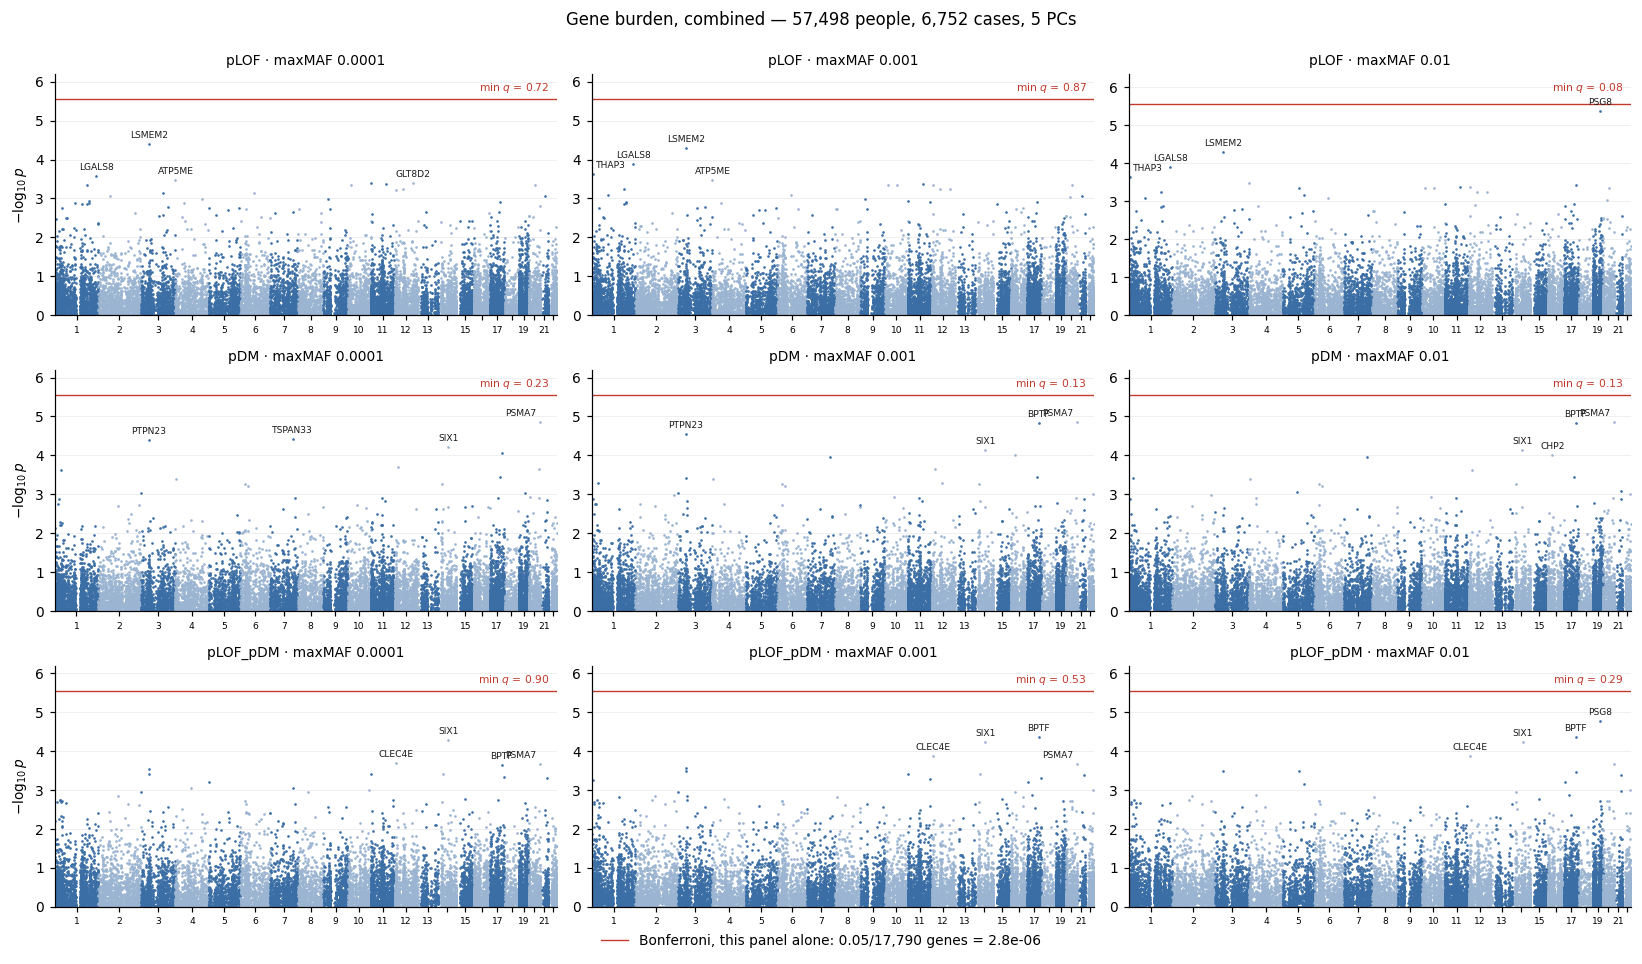

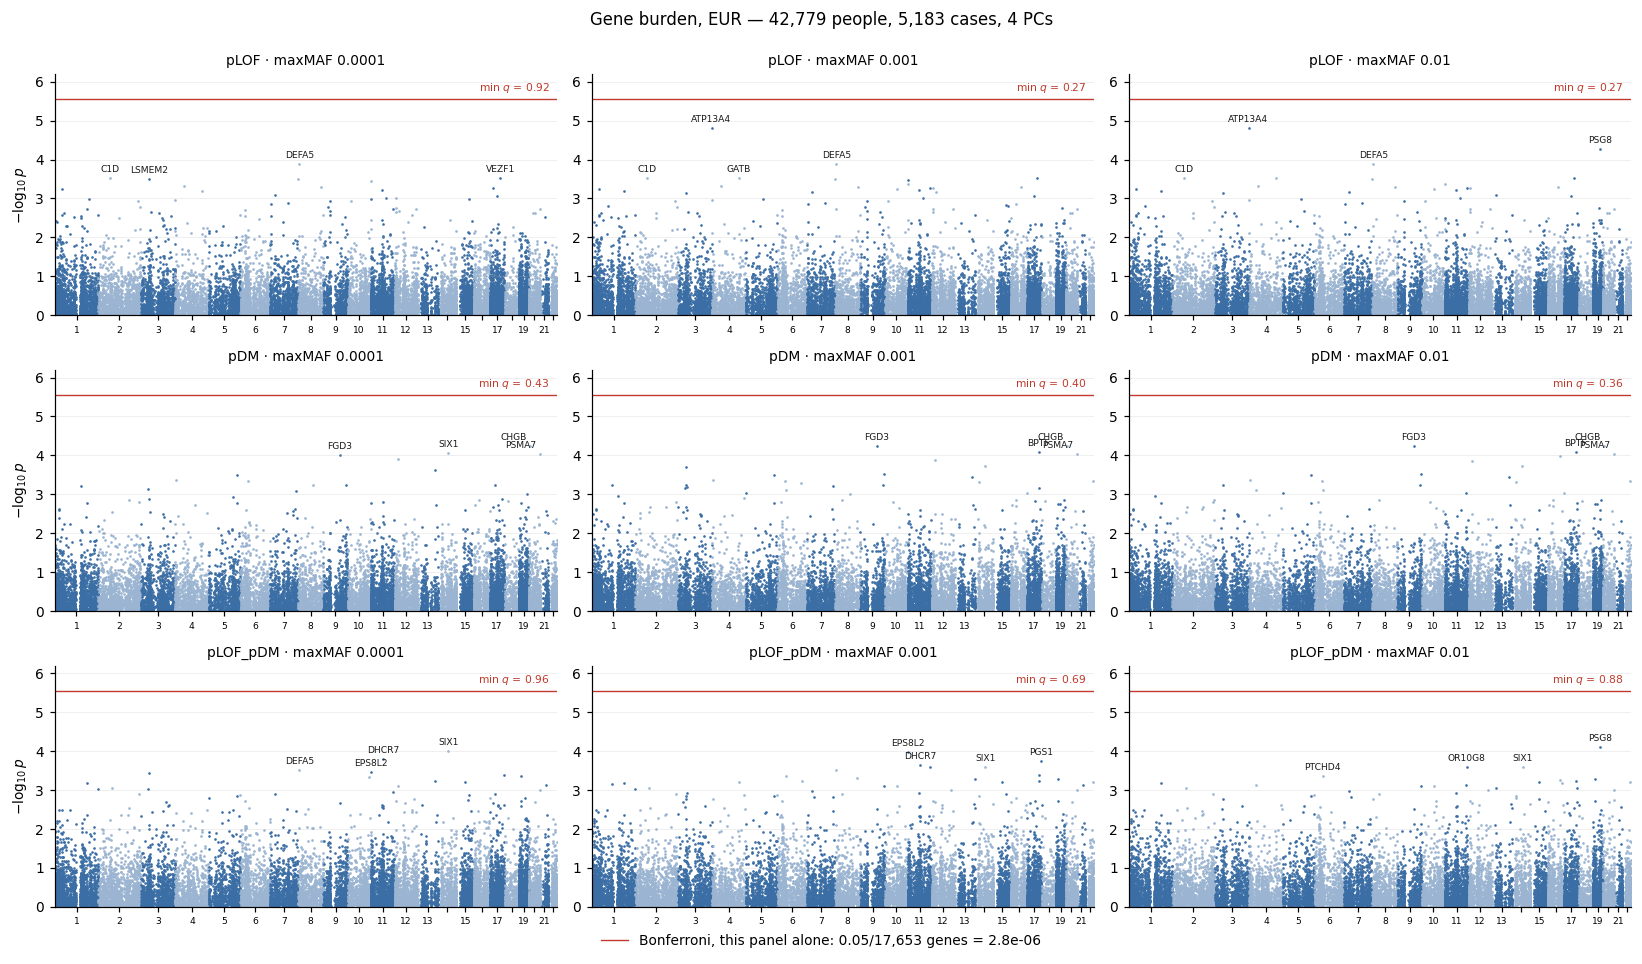

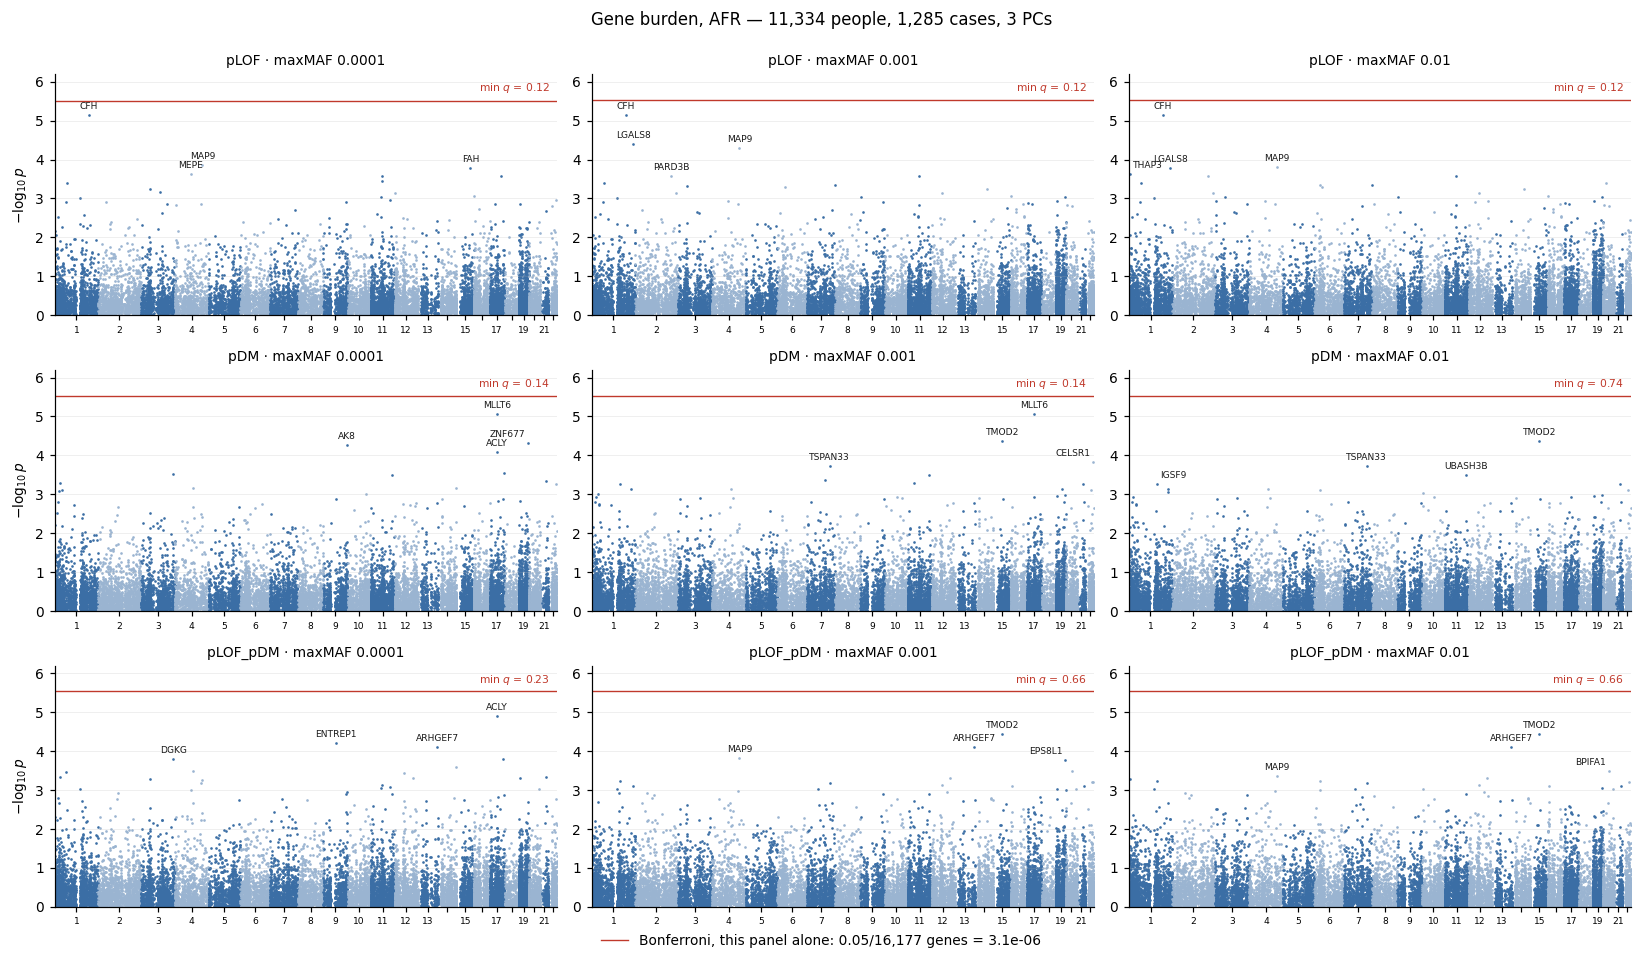

In [3]:
for cohort in bp.COHORTS:
    fig, axes = plt.subplots(3, 3, figsize=(15, 8.5))
    for i, mask in enumerate(bp.MASKS):
        for j, maf in enumerate(bp.MAFS):
            bp.manhattan(ours, cohort, ax=axes[i, j], mask=mask, maf=maf, label_top=4)
            axes[i, j].set_title(f"{mask} · maxMAF {maf}", fontsize=9)
            if i < 2:
                axes[i, j].set_xlabel("")
            if j > 0:
                axes[i, j].set_ylabel("")
    h, l = axes[0, 0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(f"Gene burden, {cohort} — {bp.N[cohort]:,} people, "
                 f"{bp.CASES[cohort]:,} cases, {bp.PCS[cohort]} PCs", y=0.995)
    fig.tight_layout()
    fig.savefig(f"../figures/manhattan_{cohort}.png")
    plt.show()

### Which bar the red line is, and FDR

The line on each panel is **Bonferroni over the genes in that panel** — nine separate corrections per
cohort, each treating its panel as if it were the whole analysis. That is the most permissive bar in
play; it does not charge for having scanned nine panels. It is drawn because nothing crosses even it,
so the conclusion does not turn on the choice.

Benjamini-Hochberg is the lenient correction and the place a weak but real effect shows up first, so
"nothing under Bonferroni" and "nothing under FDR either" are different strengths of claim. No FDR
line is drawn, because BH's cutoff is the largest p with q < 0.05 and there is none — each panel is
annotated with its smallest q instead.

In [4]:
from statsmodels.stats.multitest import multipletests

rows = []
for cohort in bp.COHORTS:
    s = ours[ours.Cohort == cohort]
    q_cohort = multipletests(s.Pvalue.values, method="fdr_bh")[1]
    q_panel = (s.groupby(["Mask", "max_MAF"]).Pvalue
                .transform(lambda x: multipletests(x.values, method="fdr_bh")[1]))
    rows.append({"cohort": cohort,
                 "min q within a panel": round(q_panel.min(), 3),
                 "min q over the cohort": round(q_cohort.min(), 3),
                 "genes at q < 0.05": int((q_cohort < 0.05).sum())})
pd.DataFrame(rows)

,cohort,min q within a panel,min q over the cohort,genes at q < 0.05
0,combined,0.075,0.374,0
1,EUR,0.271,0.785,0
2,AFR,0.117,0.260,0


Zero in every cohort, at either level. The q-values themselves say more than the count: the best
gene in each cohort carries between a 26% and a 79% chance of being a false positive once the cohort
is taken as a whole. That is not a narrow miss.

## 3. QQ, and whether the null is real

"Nothing passed the bar" and "there is nothing here" are different claims, and a conservative test
produces the first without supporting the second. The QQ plot is how you tell them apart.

λ is computed with the exact `qchisq(0.5, 1)` = 0.4549364, not the 0.456 in her
`step10_1_QQplot.R`, which inflates λ by 0.23%. It changes no conclusion and is free to get right.

λ on a SKAT-O p-value needs a word of defence, since λ is built for single-variant tests where the
null statistic is chi-square on 1 df and SKAT-O's is not. It still works, because what is being
tested is whether the p-values are **uniform**: if they are, the median of `qchisq(1-p, 1)` is
`qchisq(0.5, 1)` whatever produced them.

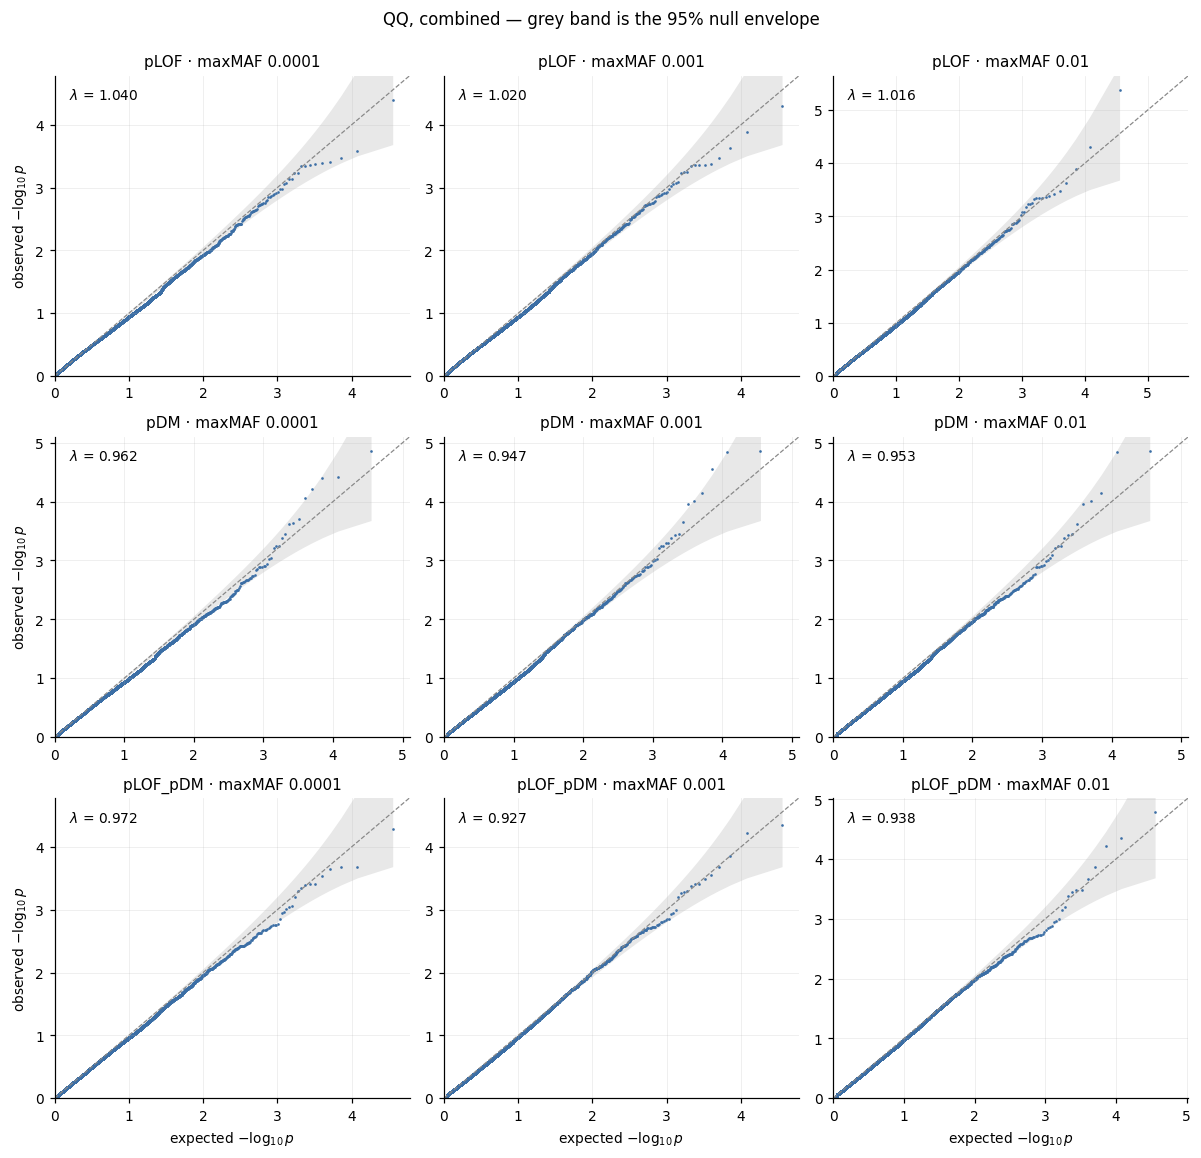

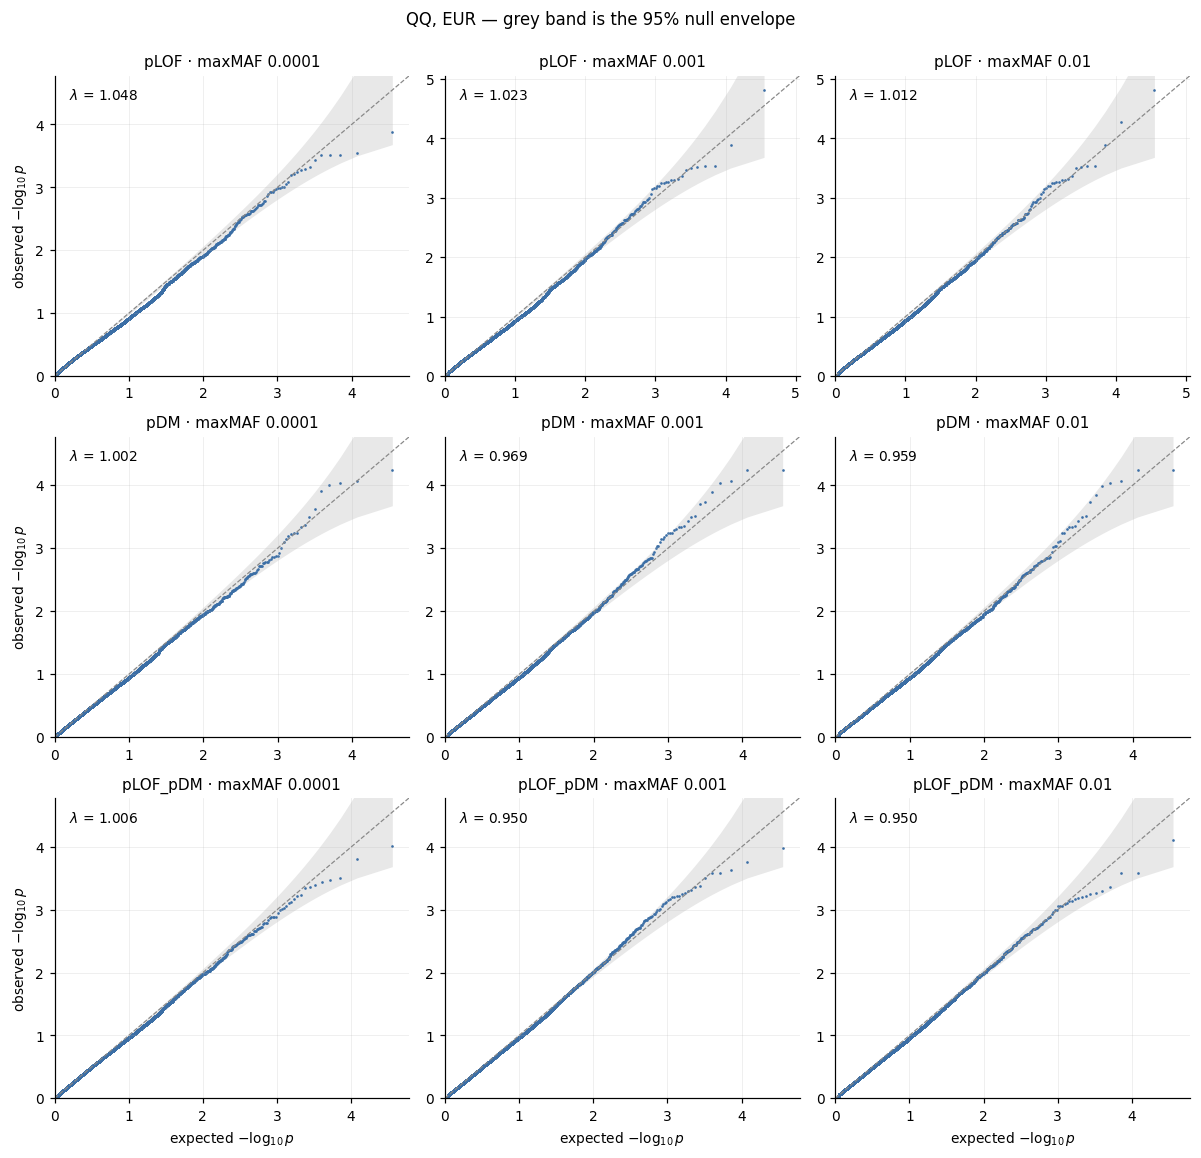

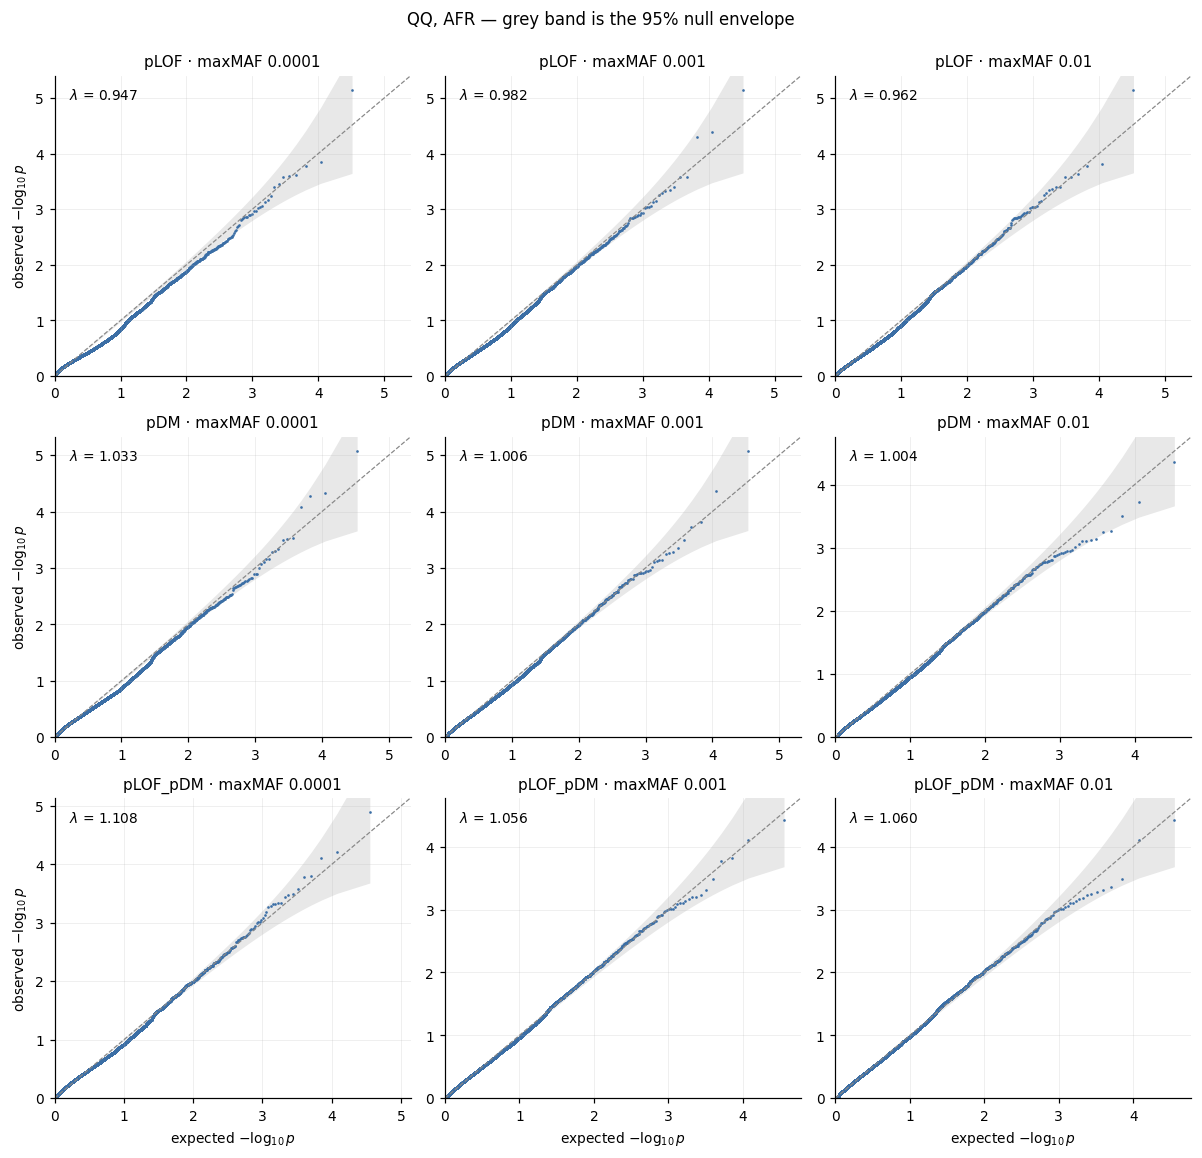

In [5]:
for cohort in bp.COHORTS:
    fig, axes = plt.subplots(3, 3, figsize=(11, 10.5))
    for i, mask in enumerate(bp.MASKS):
        for j, maf in enumerate(bp.MAFS):
            s = ours[(ours.Cohort == cohort) & (ours.Mask == mask) & (ours.max_MAF == maf)]
            bp.qq(s.Pvalue, ax=axes[i, j], title=f"{mask} · maxMAF {maf}")
            if i < 2:
                axes[i, j].set_xlabel("")
            if j > 0:
                axes[i, j].set_ylabel("")
    fig.suptitle(f"QQ, {cohort} — grey band is the 95% null envelope", y=0.997)
    fig.tight_layout()
    fig.savefig(f"../figures/qq_{cohort}.png")
    plt.show()

### λ in one table

Below 1 means conservative, above means inflated. Anything far from 1 would make the p-values
unusable, and nothing here is far from 1.

In [6]:
lam = (ours.groupby(["Cohort", "Mask", "max_MAF"])
            .Pvalue.apply(bp.lam)
            .unstack("max_MAF")
            .round(3))
lam.loc[bp.COHORTS]

max_MAF            0.0001  0.0010  0.0100
Cohort   Mask                            
combined pDM        0.962   0.947   0.953
         pLOF       1.040   1.020   1.016
         pLOF_pDM   0.972   0.927   0.938
EUR      pDM        1.002   0.969   0.959
         pLOF       1.048   1.023   1.012
         pLOF_pDM   1.006   0.950   0.950
AFR      pDM        1.033   1.006   1.004
         pLOF       0.947   0.982   0.962
         pLOF_pDM   1.108   1.056   1.060

## 4. Ours against hers

This is the figure the replication exists to produce. One point per gene, best p across the grid,
her value on x and ours on y. Points on the diagonal are genes the corrections left alone.

The red strip along the bottom is the genes she tested that our Phase 2 rebuild removed as not
protein-coding. They have no y value because we never tested them, and leaving them out of the
picture would hide the single most consequential difference between the two arms — **the rightmost
mark in the combined panel is `TMC3-AS1`, the top gene in her results, a lncRNA whose entire
result rests on two variants.**

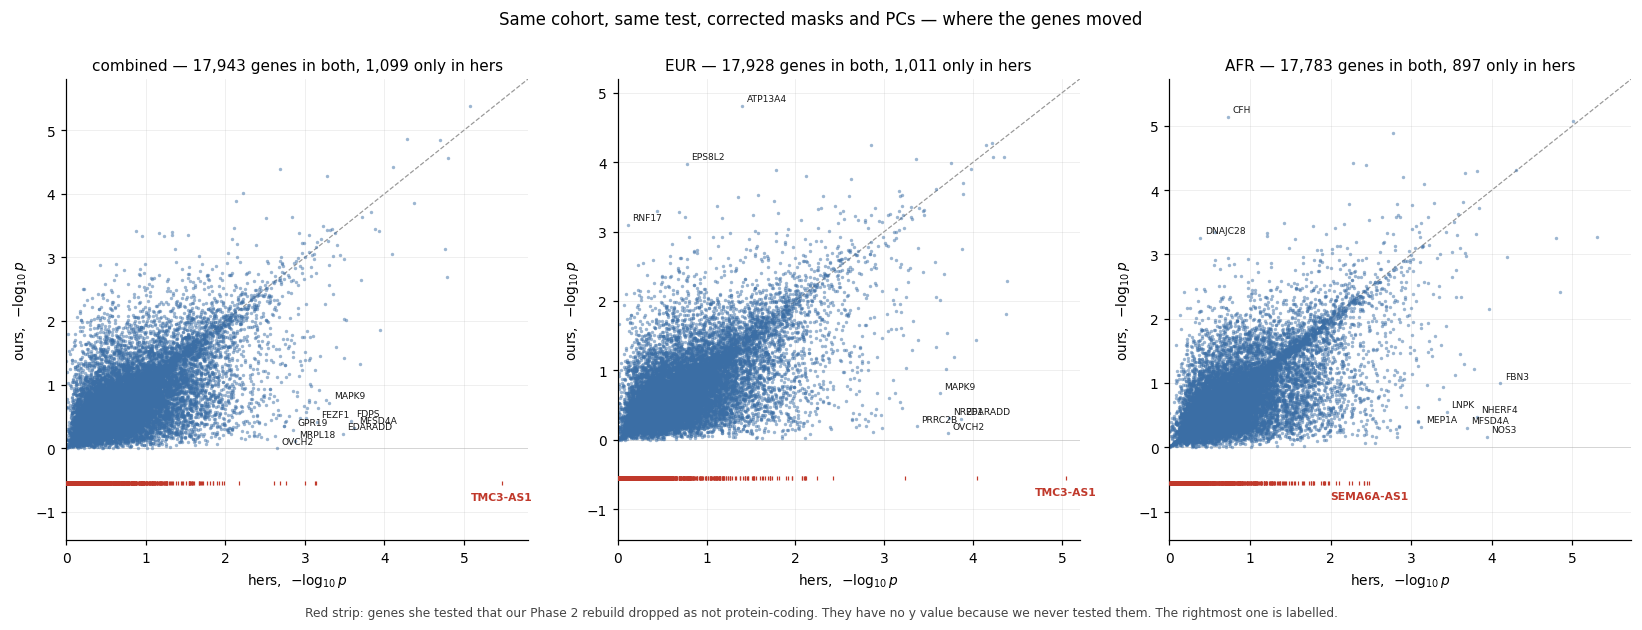

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.4))
for ax, cohort in zip(axes, bp.COHORTS):
    bp.comparison(ours, theirs, cohort, ax=ax)
fig.suptitle("Same cohort, same test, corrected masks and PCs — where the genes moved", y=1.0)
fig.text(0.5, -0.02,
         "Red strip: genes she tested that our Phase 2 rebuild dropped as not protein-coding. "
         "They have no y value because we never tested them. The rightmost one is labelled.",
         ha="center", fontsize=8, color="#444444")
fig.tight_layout()
fig.savefig("../figures/comparison_ours_vs_hers.png")
plt.show()

### How much of each top-50 list is shared

In [8]:
for cohort in bp.COHORTS:
    o = ours[ours.Cohort == cohort].groupby("Region").Pvalue.min().nsmallest(50)
    t = theirs[theirs.Cohort == cohort].groupby("Region").Pvalue.min().nsmallest(50)
    shared = set(o.index) & set(t.index)
    print(f"{cohort:9s} {len(shared):>2}/50 shared   "
          f"{sorted(shared)[:6]} ...")

combined  24/50 shared   ['AVIL', 'BPTF', 'C17orf58', 'C17orf67', 'CHL1', 'CIMIP1'] ...


EUR       17/50 shared   ['BPTF', 'C1D', 'CFAP157', 'CHGB', 'ESRP2', 'FAM83A'] ...


AFR       15/50 shared   ['AK8', 'CELSR1', 'DGKG', 'ECEL1', 'IGSF9', 'MAP9'] ...


## 5. The tables

`top_hits` carries a `fragile` flag, because a p-value alone ranks a five-allele gene alongside a
four-hundred-allele one. A test is flagged when the burden component disagrees with the combined p
— the signal is all SKAT, with no consistent direction — or when the whole gene collapsed into a
single unit, or when the MAC is under 20.

Read the flagged fraction before reading the genes: in AFR, 26 of the top 30 are flagged. That is
the cohort size showing up, not a list of candidates.

In [9]:
for cohort in bp.COHORTS:
    t = pd.read_csv(f"../results/top_hits_{cohort}.tsv", sep="\t")
    print(f"=== {cohort}: {int(t.fragile.sum())} of {len(t)} flagged fragile")
    display(t.head(8)[["rank", "Region", "Mask", "max_MAF", "Pvalue",
                       "Pvalue_Burden", "MAC", "MAC_case", "fragile", "why_fragile"]])

=== combined: 16 of 30 flagged fragile


,rank,Region,Mask,max_MAF,Pvalue,Pvalue_Burden,MAC,MAC_case,fragile,why_fragile
0,1,PSG8,pLOF,0.0100,0.000004,0.400967,366,52,True,burden disagrees
1,2,PSMA7,pDM,0.0001,0.000014,0.000014,34,14,True,collapsed to one unit
2,3,BPTF,pDM,0.0010,0.000014,0.000054,334,67,False,-
3,4,PTPN23,pDM,0.0010,0.000027,0.000060,271,53,False,-
4,5,TSPAN33,pDM,0.0001,0.000038,0.000038,30,11,True,collapsed to one unit
5,6,LSMEM2,pLOF,0.0001,0.000041,0.000041,36,13,True,collapsed to one unit
6,7,SIX1,pLOF_pDM,0.0001,0.000052,0.000052,68,18,True,collapsed to one unit
7,8,CHP2,pDM,0.0010,0.000096,0.000058,150,29,False,-


=== EUR: 18 of 30 flagged fragile


,rank,Region,Mask,max_MAF,Pvalue,Pvalue_Burden,MAC,MAC_case,fragile,why_fragile
0,1,ATP13A4,pLOF,0.0010,0.000015,0.000090,112,25,False,-
1,2,PSG8,pLOF,0.0100,0.000053,0.015871,201,42,True,burden disagrees
2,3,FGD3,pDM,0.0010,0.000057,0.174981,118,17,True,burden disagrees
3,4,CHGB,pDM,0.0001,0.000057,0.000057,11,7,True,"collapsed to one unit, MAC=11"
4,5,BPTF,pDM,0.0010,0.000084,0.000190,278,59,False,-
5,6,SIX1,pDM,0.0001,0.000085,0.000085,33,11,True,collapsed to one unit
6,7,PSMA7,pDM,0.0001,0.000091,0.000091,20,9,True,collapsed to one unit
7,8,ESRP2,pDM,0.0100,0.000103,0.000222,223,45,False,-


=== AFR: 26 of 30 flagged fragile


,rank,Region,Mask,max_MAF,Pvalue,Pvalue_Burden,MAC,MAC_case,fragile,why_fragile
0,1,CFH,pLOF,0.0001,0.000007,0.000007,5,5,True,"collapsed to one unit, MAC=5"
1,2,MLLT6,pDM,0.0001,0.000008,0.000008,6,5,True,"collapsed to one unit, MAC=6"
2,3,ACLY,pLOF_pDM,0.0001,0.000013,0.000013,44,15,True,collapsed to one unit
3,4,TMOD2,pLOF_pDM,0.0010,0.000037,0.000037,29,12,True,collapsed to one unit
4,5,LGALS8,pLOF,0.0010,0.000040,0.006266,53,13,True,burden disagrees
5,6,ZNF677,pDM,0.0001,0.000048,0.000048,13,7,True,"collapsed to one unit, MAC=13"
6,7,MAP9,pLOF,0.0010,0.000050,0.071956,58,11,True,burden disagrees
7,8,AK8,pDM,0.0001,0.000053,0.000053,21,9,True,collapsed to one unit


### The genes that left the top

Her highest-ranked genes that we never tested, with the biotype that removed them.

In [10]:
dropped = pd.read_csv("../results/dropped_from_top.tsv", sep="\t")
dropped.groupby("Cohort").head(5)[["Cohort", "Region", "her_pvalue", "her_rank", "biotype"]]

,Cohort,Region,her_pvalue,her_rank,biotype
0,combined,TMC3-AS1,0.000003,1,lncRNA
1,combined,NUP153-AS1,0.000723,48,lncRNA
2,combined,TRGV9,0.000747,52,TR_V_gene
3,combined,AGAP13P,0.001006,75,transcribed_unprocessed_pseudogene
4,combined,PRSS46P,0.001740,129,lncRNA
25,EUR,TMC3-AS1,0.000009,1,lncRNA
26,EUR,SLCO1B7,0.000091,8,transcribed_unprocessed_pseudogene
27,EUR,TRGV9,0.000579,47,TR_V_gene
28,EUR,NUP153-AS1,0.003773,268,lncRNA
29,EUR,RUFY1-AS1,0.005667,384,lncRNA


## What this phase concludes

1. **No finding.** Nothing is exome-wide significant in either arm, under any bar.
2. **The absence is real.** λ sits between 0.95 and 1.11 across all 27 panels, and the QQ points
   stay inside the null envelope. The test is calibrated, slightly conservative, and simply has
   nothing to report.
3. **The corrections still mattered.** Between 15 and 24 of each top-50 list changes, and her
   rank-1 gene is a lncRNA we never tested. In a larger cohort, or in any study that picks
   follow-up genes from a table like this, that difference decides what gets looked at.

A negative result with a methodological finding inside it, which is a different thing from — and
more useful than — a study that finds nothing and learns nothing.